# OS Places API: Address Matching Analysis

## Objectives
This notebook analyzes the feasibility and performance of using the **OS Places API** to match EPC records missing a UPRN. We focus on three key areas:

1.  **Scalability**: Can the API handle the volume within our pipeline's constraints?
2.  **Accuracy Profiling**: When the API is confident, is it actually right? (Using "Ground Truth" data).
3.  **Threshold Recommendation**: At what score does the risk of a "wrong match" outweigh the benefit of a "match"?

> **Note on Selection Bias**: We use EPC records that *already have* a UPRN as our "Ground Truth" for testing. These are likely "easier" addresses to match than the 5% that are missing UPRNs. Therefore, the performance metrics observed here represent an **upper bound** (best-case scenario).

In [162]:
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Load environment variables
load_dotenv("../.env")
os_places_key = os.environ.get("OS_PLACES_KEY")

if not os_places_key:
    print("WARNING: OS_PLACES_KEY not found. Please set it in your .env file.")
else:
    print("OS Places API Key loaded.")

OS Places API Key loaded.


In [ ]:
# Database Connection Details
DB_HOST = "DB_HOST"
DB_PORT = "DB_PORT"
DB_NAME = "mydatabase"
DB_USER = "myuser"
DB_PASS = "mypassword"

def get_db_connection():
    """Creates a SQLAlchemy engine for the Postgres database."""
    connection_str = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(connection_str)
    return engine

print("Database configuration loaded.")

Database configuration loaded.


## 1. Loading a dataset of EPC records with a unique address and *with* a UPRN.

We connect to the local Postgres instance to fetch EPC records. 
We specifically look for records that **HAVE a UPRN** to serve as our "Ground Truth" for accuracy profiling. We ensure this dataset contains distinct addresses.

In [164]:
SAMPLE_SIZE=10000

engine = get_db_connection()
query = f"""
select distinct on (query_address)
	query_address, 
	"LODGEMENT_DATE",
	"UPRN" as true_uprn
from (
	SELECT 
	    UPPER("ADDRESS") || ', ' || UPPER("POSTTOWN") || ', ' || UPPER("POSTCODE") as query_address,
	    "LODGEMENT_DATE",
	    "UPRN"
	FROM "raw_data_sdk".certificates 
	WHERE "UPRN" != '') t
order by query_address, "LODGEMENT_DATE" desc
LIMIT {SAMPLE_SIZE};
"""

df_ground_truth = pd.read_sql(query, engine)
print(f"Successfully loaded {len(df_ground_truth)} records from Postgres.")

df_ground_truth.head()


Successfully loaded 10000 records from Postgres.


,query_address,LODGEMENT_DATE,true_uprn
0,"1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2023-09-22,200003826405
1,"1001, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2013-10-20,200003826405
2,"1003, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2018-02-10,200003820360
3,"1005, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2013-07-29,200003823433
4,"1008, OLD LODE LANE, SOLIHULL, B92 8LJ",2020-01-11,100071004311


## 2. Preparing API functions
Below are the functions that we are going to use to query the OS Places API to match the addresses in our dataset. The functions below take into account rate limits and enable multi-threaded processing to ensure data is matched as quickly as possible without exceeding rate limits. 

In [143]:

import logging, threading, time
from queue import Queue
from concurrent.futures import ThreadPoolExecutor
from osdatahub import PlacesAPI

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)

# Try to use pyrate_limiter if available for precise rate control
try:
    from pyrate_limiter import Duration, RequestRate, Limiter, BucketFullException
    _HAS_PYRATE = True
except ImportError:
    _HAS_PYRATE = False
    BucketFullException = Exception  # placeholder

# Reuse existing client if already created, otherwise create now
places_api = PlacesAPI(os_places_key)

# Global backoff point shared across workers after 429s
stop_until = 0.0
stop_lock = threading.Lock()

class RateLimiter:
    def __init__(self, per_minute: int):
        # seconds between allowed calls based on per-minute cap (fallback)
        self.interval = 60.0 / per_minute
        self.lock = threading.Lock()
        self.next_time = time.time()
        if _HAS_PYRATE:
            self.limiter = Limiter(RequestRate(per_minute, Duration.MINUTE))
        else:
            self.limiter = None

    def wait(self, identity="os-places"):
        """Enforce global 429 backoff + steady spacing."""
        global stop_until
        # Honor any active 429 pause
        while True:
            with stop_lock:
                now = time.time()
                delay = stop_until - now
            if delay > 0:
                time.sleep(delay)
            else:
                break
        # Use pyrate_limiter if present; otherwise fallback to simple spacing
        if self.limiter:
            while True:
                try:
                    self.limiter.try_acquire(identity)
                    break
                except BucketFullException as exc:
                    time.sleep(getattr(exc, "meta_info", {}).get("remaining_time", self.interval))
        else:
            with self.lock:
                now = time.time()
                if now < self.next_time:
                    time.sleep(self.next_time - now)
                self.next_time = time.time() + self.interval

def _extract_match_values(results):
    if not (results and results.get("features")):
        return None
    props = results["features"][0].get("properties", {})
    return props.get("UPRN"), props.get("MATCH"), props.get("MATCH_DESCRIPTION")

def _handle_rate_limit_pause(error):
    global stop_until
    response = getattr(error, "response", None)
    retry_after = getattr(response, "headers", {}).get("Retry-After") if response else None
    retry_after = float(retry_after) if retry_after is not None else 5.0
    with stop_lock:
        stop_until = max(stop_until, time.time() + retry_after)
    return retry_after

def match_single_address(query, minmatch=0.1, limit=1, max_retries=3):
    """
    Look up one address via OS Places, with simple retries and debug prints.
    Returns (uprn, match_score, match_description).
    """
    backoff = 1
    for attempt in range(1, max_retries + 1):
        try:
            results = places_api.find(text=query, minmatch=minmatch, limit=limit)
        except Exception as e:
            status = getattr(getattr(e, "response", None), "status_code", None)
            if status == 429:
                retry_after = _handle_rate_limit_pause(e)
                logging.warning(
                    f"429 for '{query}', pausing all workers for {retry_after}s (attempt {attempt}/{max_retries})"
                )
                continue
            logging.warning(
                f"osdatahub request failed for '{query}' (attempt {attempt}/{max_retries}): {e}"
            )
            time.sleep(backoff)
            backoff *= 2
            continue

        matched = _extract_match_values(results)
        if matched:
            return matched
        print(f"[single] No results for '{query}' on attempt {attempt}")

    print(f"[single] Exhausted retries for '{query}'")
    return None, 0.0, None

def match_addresses_threaded(addresses, max_workers=2, per_minute=50, log_every=50):
    """
    Threaded wrapper around match_single_address with rate limiting.
    Prints progress and per-task debug info.
    """
    print(f"Logging approximately every {log_every} records")
    if _HAS_PYRATE:
        print("Using pyrate_limiter for rate control")
    limiter = RateLimiter(per_minute)
    q = Queue()
    for item in enumerate(addresses):
        q.put(item)
    results = [None] * len(addresses)
    started = time.time()

    def worker(worker_id):
        while True:
            try:
                idx, addr = q.get_nowait()
            except Exception:
                print(f"[worker {worker_id}] queue empty, exiting")
                break
            limiter.wait(identity=f"w{worker_id}")
            uprn, score, match_desc = match_single_address(addr)
            results[idx] = (addr, uprn, score, match_desc)
            if idx % log_every == 0:
                done = sum(r is not None for r in results)
                rate = done / max(time.time() - started, 1)
                logging.info(f"[worker {worker_id}] processing idx={idx} addr='{addr}'")
                logging.info(f"Progress: {done}/{len(addresses)} ({rate:.2f} req/s)")
            q.task_done()

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for worker_id in range(max_workers):
            ex.submit(worker, worker_id)
        q.join()

    elapsed = time.time() - started
    logging.info(
        f"Finished {len(addresses)} in {elapsed/60:.2f} min ({len(addresses)/max(elapsed,1):.2f} req/s)"
    )
    print(f"[threaded] results collected: {sum(r is not None for r in results)} / {len(results)}")
    return results



### 2.1 Single vs multi-threaded API requests.

Below is a comparison of the a single vs multi-threaded approach to API requests over a sample of 100 records.


In [138]:
sample_size = 100
estimated_total_records = 1250000 # expected volume at national scale
sample = df_ground_truth['query_address'][:sample_size].tolist()

In [139]:
start_time = time.time()

for address in sample:
    match_single_address(query=address)

end_time = time.time()
avg_time = (end_time - start_time) / sample_size

total_time_hours = (avg_time * estimated_total_records) / 3600

print(f"Average Latency: {avg_time:.4f} seconds/request")
print(f"Estimated time for {estimated_total_records} records: {total_time_hours:.2f} hours")

Average Latency: 0.9103 seconds/request
Estimated time for 1250000 records: 316.08 hours


In [140]:
start_time = time.time()
sample_matches = match_addresses_threaded(sample, max_workers=2, per_minute=50, log_every=20)
end_time = time.time()
avg_time = (end_time - start_time) / len(sample)

total_time_hours = (avg_time * estimated_total_records) / 3600

print(f"Average Latency: {avg_time:.4f} seconds/request")
print(f"Estimated time for {estimated_total_records} records (not considering RATE LIMITS): {total_time_hours:.2f} hours")

Logging approximately every 20 records


16:10:40 [INFO] [worker 0] processing idx=0 addr='1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG'
16:10:40 [INFO] Progress: 1/100 (0.68 req/s)
16:11:03 [INFO] [worker 1] processing idx=20 addr='100, CAMBRIDGE DRIVE, BIRMINGHAM, B37 5NT'
16:11:03 [INFO] Progress: 21/100 (0.86 req/s)
16:11:28 [INFO] [worker 0] processing idx=40 addr='100, GREEN HILL WAY, SHIRLEY, SOLIHULL, B90 3PY'
16:11:28 [INFO] Progress: 41/100 (0.84 req/s)
16:11:52 [INFO] [worker 1] processing idx=60 addr='100, KINETON GREEN ROAD, SOLIHULL, B92 7EE'
16:11:52 [INFO] Progress: 61/100 (0.83 req/s)
16:12:15 [INFO] [worker 0] processing idx=80 addr='100 MIDDLEWOOD CLOSE, SOLIHULL, B91 2TY'
16:12:15 [INFO] Progress: 81/100 (0.84 req/s)


[worker 0] queue empty, exiting


16:12:38 [INFO] Finished 100 in 1.99 min (0.84 req/s)


[worker 1] queue empty, exiting
[threaded] results collected: 100 / 100
Average Latency: 1.1937 seconds/request
Estimated time for 1250000 records (not considering RATE LIMITS): 414.48 hours


In [141]:
pd.DataFrame(sample_matches, columns=["query_address", "pred_uprn", "match_score", "match_description"])

,query_address,pred_uprn,match_score,match_description
0,"1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003826405,0.9,GOOD
1,"1001, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003826405,1.0,EXACT
2,"1003, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003820360,1.0,EXACT
3,"1005, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003823433,1.0,EXACT
4,"1008, OLD LODE LANE, SOLIHULL, B92 8LJ",100071004311,1.0,EXACT
...,...,...,...,...
95,"100, PARKFIELD DRIVE, BIRMINGHAM, B36 9EJ",100070965561,1.0,EXACT
96,"100, PARK HALL CRESCENT, BIRMINGHAM, B36 9SU",100070965462,1.0,EXACT
97,"100, PERCH AVENUE, BIRMINGHAM, B37 5NA",100070965856,1.0,EXACT
98,"100, PICCADILLY CLOSE, BIRMINGHAM, B37 7LQ",100070966032,1.0,EXACT


### 2.2 Address matching
We now have a ground truth dataset and the necessary API functions to use the OS Places API as an address matching tool. Let's now call the OS Places API to address match our ground truth dataset.

In [144]:
print("Running matching (pass 1)...")

matches = match_addresses_threaded(
    df_ground_truth['query_address'].to_list(),
    max_workers=2,
    per_minute=50,
    log_every=1000,
)
matches_df = pd.DataFrame(matches, columns=["query_address", "pred_uprn", "match_score", "match_description"])

Running matching (pass 1)...
Logging approximately every 1000 records


16:23:28 [INFO] [worker 0] processing idx=0 addr='1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG'
16:23:28 [INFO] Progress: 1/10000 (0.70 req/s)
16:43:28 [INFO] [worker 1] processing idx=1000 addr='106, STRETTON ROAD, SHIRLEY, SOLIHULL, B90 2RX'
16:43:28 [INFO] Progress: 1001/10000 (0.83 req/s)
17:03:27 [INFO] [worker 0] processing idx=2000 addr='10 JERSEY CROFT, BIRMINGHAM, B36 0PD'
17:03:27 [INFO] Progress: 2001/10000 (0.83 req/s)
17:23:29 [INFO] [worker 0] processing idx=3000 addr='112 WATER ORTON ROAD, BIRMINGHAM, B36 9HE'
17:23:29 [INFO] Progress: 3001/10000 (0.83 req/s)
17:43:28 [INFO] [worker 0] processing idx=4000 addr='11, BLYTHEWOOD CLOSE, SOLIHULL, B91 3HL'
17:43:28 [INFO] Progress: 4001/10000 (0.83 req/s)
18:04:12 [INFO] [worker 0] processing idx=5000 addr='11, WISHAW GROVE, BIRMINGHAM, B37 6DS'
18:04:12 [INFO] Progress: 5001/10000 (0.83 req/s)
18:24:14 [INFO] [worker 1] processing idx=6000 addr='129 VELSHEDA ROAD, SHIRLEY, SOLIHULL, SOLIHULL, B90 2JP'
18:24:14 [INFO] Prog

[worker 0] queue empty, exiting


19:47:06 [INFO] Finished 10000 in 203.66 min (0.82 req/s)


[worker 1] queue empty, exiting
[threaded] results collected: 10000 / 10000


In [145]:
# save results
matches_df.to_csv("matches.csv", index=False)

## 3. Address matching performance

**Binary classification problem:**
Decide whether to accept the OS Places candidate (positive) or treat it as no-match/needs review (negative) based on the match score.

**Decision rule:** if the score is above threshold T, classify record as positive otherwise negative.

**Ground truth label:** is_correct is True when the API-returned UPRN matches the true UPRN.

We will now run the matching algorithm on our "Ground Truth" dataset of records with a UPRN.

*Retrieving our results from the OS Places API.*

In [156]:
matches_df = pd.read_csv("matches.csv")
matches_df["pred_uprn"] = matches_df["pred_uprn"].astype(str)
matches_df.head()

,query_address,pred_uprn,match_score,match_description
0,"1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003826405,0.9,GOOD
1,"1001, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003826405,1.0,EXACT
2,"1003, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003820360,1.0,EXACT
3,"1005, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",200003823433,1.0,EXACT
4,"1008, OLD LODE LANE, SOLIHULL, B92 8LJ",100071004311,1.0,EXACT


*Merging API results back to our ground truth dataset.*

In [157]:
merged = df_ground_truth.merge(
    right=matches_df, 
    on="query_address", 
    how="left"
)
merged["is_correct"] = merged.apply(lambda x: x["true_uprn"]==x["pred_uprn"], axis=1)
merged.head()

,query_address,LODGEMENT_DATE,true_uprn,pred_uprn,match_score,match_description,is_correct
0,"1001 STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2023-09-22,200003826405,200003826405,0.9,GOOD,True
1,"1001, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2013-10-20,200003826405,200003826405,1.0,EXACT,True
2,"1003, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2018-02-10,200003820360,200003820360,1.0,EXACT,True
3,"1005, STRATFORD ROAD, SHIRLEY, SOLIHULL, B90 4BG",2013-07-29,200003823433,200003823433,1.0,EXACT,True
4,"1008, OLD LODE LANE, SOLIHULL, B92 8LJ",2020-01-11,100071004311,100071004311,1.0,EXACT,True


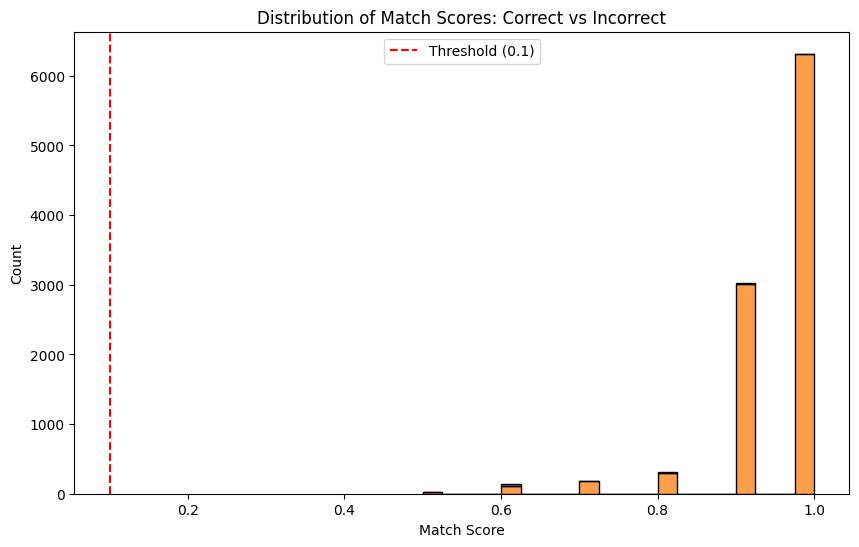

is_correct
True     0.9935
False    0.0065
Name: proportion, dtype: float64


In [158]:
plt.figure(figsize=(10, 6))
sns.histplot(data=merged, x="match_score", hue="is_correct", multiple="stack", bins=20)
plt.title("Distribution of Match Scores: Correct vs Incorrect")
plt.xlabel("Match Score")
plt.ylabel("Count")
plt.axvline(0.1, color='r', linestyle='--', label='Threshold (0.1)')
plt.legend()
plt.show()

print(merged["is_correct"].value_counts(normalize=True))

### 3.1 Threshold analysis

We calculate **Precision** and **Recall** at various thresholds to find the sweet spot.

*   **Precision**: Of the matches we accepted (score >= T), what % were actually correct?
*   **Recall**: Of all the possible correct matches in the dataset, what % did we find?

In [166]:
thresholds = np.round(np.linspace(0.1, 1.0, 19), 2) 
metrics = []

total_true_matches = merged['is_correct'].sum() # Total possible correct matches we could find

for t in thresholds:
    # Filter by threshold
    accepted = merged[merged['match_score'] >= t]
    
    if len(accepted) == 0:
        precision = 1.0 # Technically undefined, but safe to assume high strictness
        recall = 0.0
    else:
        # Precision: % of accepted that are correct
        precision = accepted['is_correct'].mean()
        
        # Recall: % of total correct matches that were accepted
        # Note: We use total_true_matches from the whole set as the denominator
        recall = accepted['is_correct'].sum() / total_true_matches if total_true_matches > 0 else 0
        
    metrics.append({
        "Threshold": round(t, 2),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Matches Accepted": len(accepted)
    })

df_metrics = pd.DataFrame(metrics)

# Display the table
print(df_metrics.to_string(index=False))

print("Precision: the proportion of accepted records which are matched correctly. High precision reduces the number of incorrect matches being accepted.")
print("Recall: the proportion of correctly matched records which are accepted. High recall reduces the number of correct matches which are rejected.")

 Threshold  Precision  Recall  Matches Accepted
      0.10     0.9935  1.0000             10000
      0.15     0.9935  1.0000             10000
      0.20     0.9935  1.0000             10000
      0.25     0.9935  1.0000             10000
      0.30     0.9935  1.0000             10000
      0.35     0.9935  1.0000             10000
      0.40     0.9935  1.0000             10000
      0.45     0.9935  1.0000             10000
      0.50     0.9935  1.0000             10000
      0.55     0.9935  0.9976              9976
      0.60     0.9935  0.9976              9976
      0.65     0.9959  0.9867              9843
      0.70     0.9959  0.9867              9843
      0.75     0.9968  0.9687              9655
      0.80     0.9968  0.9687              9655
      0.85     0.9985  0.9387              9340
      0.90     0.9985  0.9387              9340
      0.95     0.9991  0.6352              6317
      1.00     0.9991  0.6352              6317
Precision: the proportion of accepted re

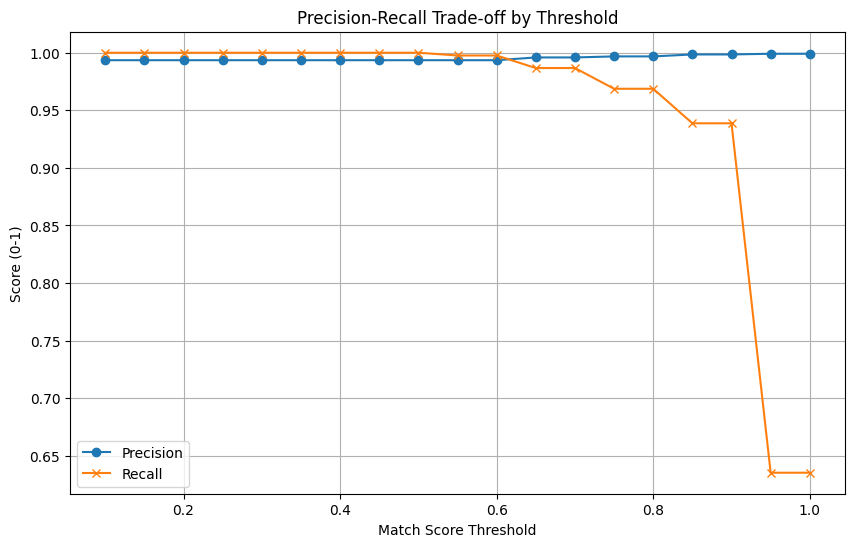

In [167]:
plt.figure(figsize=(10, 6))
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], marker='o', label='Precision')
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], marker='x', label='Recall')
plt.title("Precision-Recall Trade-off by Threshold")
plt.xlabel("Match Score Threshold")
plt.ylabel("Score (0-1)")
plt.grid(True)
plt.legend()
plt.show()

## Conclusion

On UPRN records with a UPRN, matching performance is very strong. But as shown below, records without a UPRN are much harder to match. 

Potential options moving forward:

- capture matched records and their match score and display them on the front-end with no threshold (0.1)
- capture matched records and their match score and display them on the front-end with a sensible threshold (e.g 0.7)
- only accept matched records with a high or perfect match.

Alternatives:
[AIMS API](https://github.com/ONSdigital/aims-api)

## Examples of EPC records without a UPRN

In [177]:
SAMPLE_SIZE=50

engine = get_db_connection()

# Query to fetch a sample of records with UPRNs
query = f"""
select distinct on (query_address)
    query_address, 
    "LODGEMENT_DATE",
    "UPRN" as true_uprn
from (
    SELECT 
        UPPER("ADDRESS") || ', ' || UPPER("POSTTOWN") || ', ' || UPPER("POSTCODE") as query_address,
        "LODGEMENT_DATE",
        "UPRN"
    FROM "raw_data_sdk".certificates 
    WHERE "UPRN" = '') t
order by query_address, "LODGEMENT_DATE" desc
LIMIT {SAMPLE_SIZE};
"""

df_no_uprn = pd.read_sql(query, engine)
print(f"Successfully loaded {len(df_no_uprn)} records from Postgres.")

df_no_uprn.head()

Successfully loaded 50 records from Postgres.


,query_address,LODGEMENT_DATE,true_uprn
0,"100, CREYNOLDS LANE, SHIRLEY, SOLIHULL, B90 4ER",2022-10-22,
1,"100, DUNTON ROAD, KINGSHURST, BIRMINGHAM, B37 6JL",2009-10-11,
2,"100 WEST AVENUE, CASTLE BROMWICH, SOLIHULL, B3...",2025-07-01,
3,"104, COLESHILL HEATH ROAD, BIRMINGHAM, B37 7SN",2009-02-19,
4,"104, DUNTON ROAD, KINGSHURST, BIRMINGHAM, B37 6JL",2009-09-30,


*Running the OS Places API matching on this data.*

In [173]:
print("Running matching...")

matches = match_addresses_threaded(df_no_uprn['query_address'].tolist(), max_workers=2)
matches_df = pd.DataFrame(matches, columns=["query_address", "pred_uprn", "match_score", "match_description"])

Running matching...
Logging approximately every 50 records


09:14:49 [INFO] [worker 0] processing idx=0 addr='100, CREYNOLDS LANE, SHIRLEY, SOLIHULL, B90 4ER'
09:14:49 [INFO] Progress: 1/50 (0.81 req/s)


[worker 0] queue empty, exiting


09:15:48 [INFO] Finished 50 in 1.01 min (0.83 req/s)


[worker 1] queue empty, exiting
[threaded] results collected: 50 / 50


*Joining matches back onto our source data. From here we can use tools like [FindMyAddress](https://www.findmyaddress.co.uk/) to verify whether the predicted UPRNs lead us back to the query address.*

In [176]:
merged = df_no_uprn.merge(
    right=matches_df, 
    on="query_address", 
    how="left"
)
merged

,query_address,LODGEMENT_DATE,true_uprn,pred_uprn,match_score,match_description
0,"100, CREYNOLDS LANE, SHIRLEY, SOLIHULL, B90 4ER",2022-10-22,,100071014448,0.7,PARTIAL
1,"100, DUNTON ROAD, KINGSHURST, BIRMINGHAM, B37 6JL",2009-10-11,,10023648771,0.8,GOOD
2,"100 WEST AVENUE, CASTLE BROMWICH, SOLIHULL, B3...",2025-07-01,,100070970137,0.8,GOOD
3,"104, COLESHILL HEATH ROAD, BIRMINGHAM, B37 7SN",2009-02-19,,100070955501,0.9,GOOD
4,"104, DUNTON ROAD, KINGSHURST, BIRMINGHAM, B37 6JL",2009-09-30,,100070957277,0.9,GOOD
5,"104 HASLUCKS GREEN ROAD, FLAT 7 (PLOT 104D) HA...",2021-02-24,,10008213375,0.6,NO MATCH
6,"105 ALEXANDER COURT, GOSPEL LANE, BIRMINGHAM ...",2022-01-28,,100070381469,0.6,NO MATCH
7,"106, COLESHILL HEATH ROAD, BIRMINGHAM, B37 7SN",2008-10-01,,100070955511,0.9,GOOD
8,"107, KELSEY LANE, BALSALL COMMON, COVENTRY, CV...",2025-08-15,,100070973392,1.0,EXACT
9,"10A KNIGHTSBRIDGE ROAD, SOLIHULL, B92 8RL",2015-03-30,,100071364626,0.8,GOOD
